# PTB-XL Baseline Model

## Objective

This notebook develops and evaluates a simple 1D convolutional neural network for multi-label ECG classification.

The baseline model is intended to verify that the complete training pipeline works correctly and to establish a reference performance level for comparison with more advanced architectures.

## 1. Setup

In [60]:
from pathlib import Path
import ast
import sys

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

current_path = Path.cwd().resolve()
PROJECT_ROOT = next(
    (
        path
        for path in (current_path, *current_path.parents)
        if (path / "src").is_dir()
        and (path / "data" / "ptb-xl").is_dir()
    ),
    None
)

if PROJECT_ROOT is None:
    raise FileNotFoundError("Could not locate the project root.")

DATA_DIR = PROJECT_ROOT / "data" / "ptb-xl"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT.name)
print("PyTorch version:", torch.__version__)

Project root: ecg-classification
PyTorch version: 2.13.0


In [61]:
from src.dataset import ECGDataset
from src.preprocessing import compute_dataset_stats
from src.model import ECGCNN

## 2. Preparing the Data

The PTB-XL metadata is loaded and converted into the same training, validation, and test splits established in the data pipeline. Diagnostic superclasses are encoded as five-element multi-hot target vectors.

Normalization statistics are calculated using only the training recordings. The resulting datasets load and normalize ECG waveforms on demand, while the DataLoaders group them into batches for model training and evaluation.

In [62]:
metadata_df = pd.read_csv(DATA_DIR / "ptbxl_database.csv")
scp = pd.read_csv(DATA_DIR / "scp_statements.csv", index_col=0)
diagnostic_scp = scp[scp["diagnostic"] == 1]

metadata_df["scp_codes_parsed"] = metadata_df["scp_codes"].apply(
    ast.literal_eval
)

print("Metadata shape:", metadata_df.shape)

Metadata shape: (21799, 29)


In [63]:
CLASSES = ["NORM", "MI", "STTC", "CD", "HYP"]


def get_diagnostic_classes(codes):
    classes = set()

    for code in codes:
        if code in diagnostic_scp.index:
            diagnostic_class = diagnostic_scp.loc[
                code, "diagnostic_class"
            ]

            if pd.notna(diagnostic_class):
                classes.add(diagnostic_class)

    return sorted(classes)


def encode_labels(labels):
    return [int(class_name in labels) for class_name in CLASSES]

In [64]:
metadata_df["diagnostic_classes"] = metadata_df[
    "scp_codes_parsed"
].apply(get_diagnostic_classes)

model_df = metadata_df[
    metadata_df["diagnostic_classes"].apply(len) > 0
].copy()

train_df = model_df[model_df["strat_fold"].between(1, 8)].copy()
val_df = model_df[model_df["strat_fold"] == 9].copy()
test_df = model_df[model_df["strat_fold"] == 10].copy()

for split_df in (train_df, val_df, test_df):
    split_df["labels"] = split_df["diagnostic_classes"].apply(
        encode_labels
    )

print("Training recordings:", len(train_df))
print("Validation recordings:", len(val_df))
print("Test recordings:", len(test_df))

Training recordings: 17084
Validation recordings: 2146
Test recordings: 2158


In [65]:
train_filepaths = [
    DATA_DIR / filename
    for filename in train_df["filename_lr"]
]

train_mean, train_std = compute_dataset_stats(train_filepaths)

print("Mean shape:", train_mean.shape)
print("Standard-deviation shape:", train_std.shape)

Mean shape: (12,)
Standard-deviation shape: (12,)


In [66]:
train_dataset = ECGDataset(
    train_df, DATA_DIR, train_mean, train_std
)
val_dataset = ECGDataset(
    val_df, DATA_DIR, train_mean, train_std
)
test_dataset = ECGDataset(
    test_df, DATA_DIR, train_mean, train_std
)

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False
)

In [67]:
batch_signals, batch_labels = next(iter(train_loader))

print("Signal batch shape:", batch_signals.shape)
print("Label batch shape:", batch_labels.shape)

assert batch_signals.shape == (BATCH_SIZE, 12, 1000)
assert batch_labels.shape == (BATCH_SIZE, len(CLASSES))

Signal batch shape: torch.Size([32, 12, 1000])
Label batch shape: torch.Size([32, 5])


## 3. Building the Baseline 1D CNN

The baseline model uses one-dimensional convolutional layers to identify temporal patterns in the ECG signals.

The 12 ECG leads are treated as input channels. Successive convolutional layers learn higher-level features, while pooling reduces the time dimension. The final linear layer produces one score for each of the five diagnostic superclasses.

In [68]:
from src.model import ECGCNN

model = ECGCNN(num_classes=len(CLASSES))

output = model(batch_signals)

print("Input shape:", batch_signals.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([32, 12, 1000])
Output shape: torch.Size([32, 5])


## 4. Training Configuration

The model is trained using binary cross-entropy because each diagnostic superclass is predicted independently.

`BCEWithLogitsLoss` combines the sigmoid transformation and binary cross-entropy calculation in a numerically stable operation.

The Adam optimizer is used to update the model parameters based on the calculated loss.

In [69]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

model = ECGCNN(
    num_classes=len(CLASSES)
).to(device)

Using device: mps


In [70]:
LEARNING_RATE = 0.001
NUM_EPOCHS = 10

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

print("Loss function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)

Loss function: BCEWithLogitsLoss()
Optimizer: Adam


## 5. Training and Validation

During training, the model generates predictions for each batch, calculates the loss, and updates its parameters using backpropagation.

After each training epoch, the model is evaluated on the validation set without updating its parameters. The model state with the lowest validation loss is saved for later evaluation on the test set.

In [71]:
def train_one_epoch(model, data_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for signals, labels in data_loader:
        signals = signals.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(signals)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * signals.size(0)

    return total_loss / len(data_loader.dataset)


def validate_one_epoch(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for signals, labels in data_loader:
            signals = signals.to(device)
            labels = labels.to(device)

            logits = model(signals)
            loss = criterion(logits, labels)

            total_loss += loss.item() * signals.size(0)

    return total_loss / len(data_loader.dataset)

In [72]:
MODEL_DIR = PROJECT_ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)
BEST_MODEL_PATH = MODEL_DIR / "baseline_ecg_cnn.pt"

history = {"train_loss": [], "val_loss": []}
best_val_loss = float("inf")

for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    val_loss = validate_one_epoch(
        model, val_loader, criterion, device
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), BEST_MODEL_PATH)

    print(
        f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | "
        f"Train loss: {train_loss:.4f} | "
        f"Validation loss: {val_loss:.4f}"
    )

print("Best validation loss:", round(best_val_loss, 4))
print("Saved model:", BEST_MODEL_PATH.relative_to(PROJECT_ROOT))

Epoch 01/10 | Train loss: 0.3761 | Validation loss: 0.3567
Epoch 02/10 | Train loss: 0.3157 | Validation loss: 0.3214
Epoch 03/10 | Train loss: 0.3010 | Validation loss: 0.3079
Epoch 04/10 | Train loss: 0.2912 | Validation loss: 0.3096
Epoch 05/10 | Train loss: 0.2834 | Validation loss: 0.3212
Epoch 06/10 | Train loss: 0.2786 | Validation loss: 0.2985
Epoch 07/10 | Train loss: 0.2749 | Validation loss: 0.3002
Epoch 08/10 | Train loss: 0.2700 | Validation loss: 0.2915
Epoch 09/10 | Train loss: 0.2676 | Validation loss: 0.2949
Epoch 10/10 | Train loss: 0.2641 | Validation loss: 0.2893
Best validation loss: 0.2893
Saved model: models/baseline_ecg_cnn.pt


## 6. Evaluating the Baseline Model

The model checkpoint with the lowest validation loss is loaded and evaluated on the held-out test set.

Predicted logits are converted into probabilities using the sigmoid function. A fixed threshold of `0.5` converts those probabilities into positive or negative predictions.

For each diagnostic superclass, the evaluation reports true positives, false positives, true negatives, false negatives, precision, sensitivity, specificity, F1 score, and AUROC. AUROC summarizes discrimination across all possible thresholds, while the remaining metrics describe performance at the fixed threshold.

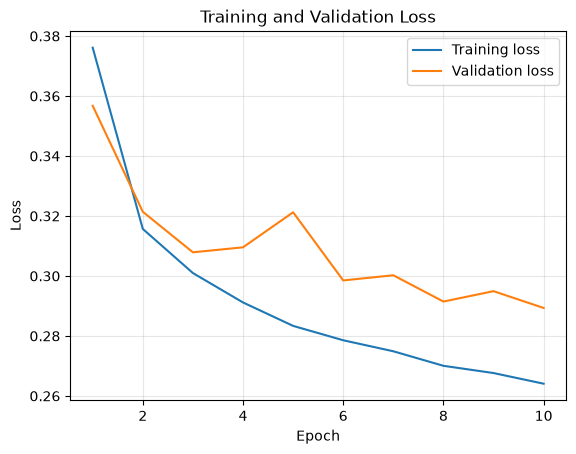

In [73]:
import matplotlib.pyplot as plt

epochs = range(1, NUM_EPOCHS + 1)

plt.plot(epochs, history["train_loss"], label="Training loss")
plt.plot(epochs, history["val_loss"], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [74]:
model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device,
        weights_only=True
    )
)

model.eval()

all_probabilities = []
all_labels = []

with torch.no_grad():
    for signals, labels in test_loader:
        signals = signals.to(device)

        logits = model(signals)
        probabilities = torch.sigmoid(logits)

        all_probabilities.append(probabilities.cpu())
        all_labels.append(labels)

test_probabilities = torch.cat(all_probabilities).numpy()
test_labels = torch.cat(all_labels).numpy()

print("Probabilities:", test_probabilities.shape)
print("Labels:", test_labels.shape)

Probabilities: (2158, 5)
Labels: (2158, 5)


In [75]:
from sklearn.metrics import confusion_matrix, f1_score, roc_auc_score

DECISION_THRESHOLD = 0.5
test_predictions = (
    test_probabilities >= DECISION_THRESHOLD
).astype(int)


def safe_divide(numerator, denominator):
    return numerator / denominator if denominator else 0.0


metric_rows = []

for class_index, class_name in enumerate(CLASSES):
    true_values = test_labels[:, class_index]
    predicted_values = test_predictions[:, class_index]

    tn, fp, fn, tp = confusion_matrix(
        true_values, predicted_values, labels=[0, 1]
    ).ravel()

    precision = safe_divide(tp, tp + fp)
    sensitivity = safe_divide(tp, tp + fn)
    specificity = safe_divide(tn, tn + fp)
    f1 = safe_divide(
        2 * precision * sensitivity,
        precision + sensitivity
    )
    auroc = roc_auc_score(
        true_values, test_probabilities[:, class_index]
    )

    metric_rows.append(
        {
            "Class": class_name,
            "TP": tp,
            "FP": fp,
            "TN": tn,
            "FN": fn,
            "Precision": precision,
            "Sensitivity": sensitivity,
            "Specificity": specificity,
            "F1": f1,
            "AUROC": auroc
        }
    )

per_class_metrics = pd.DataFrame(metric_rows).set_index("Class")
display(per_class_metrics.round(3))

overall_metrics = pd.DataFrame(
    {
        "Score": [
            f1_score(
                test_labels, test_predictions,
                average="macro", zero_division=0
            ),
            f1_score(
                test_labels, test_predictions,
                average="micro", zero_division=0
            ),
            roc_auc_score(
                test_labels, test_probabilities, average="macro"
            ),
            roc_auc_score(
                test_labels, test_probabilities, average="micro"
            )
        ]
    },
    index=[
        "Macro F1", "Micro F1",
        "Macro AUROC", "Micro AUROC"
    ]
)

display(overall_metrics.round(3))

,TP,FP,TN,FN,Precision,Sensitivity,Specificity,F1,AUROC
Class,,,,,,,,,
NORM,874,230,965,89,0.792,0.908,0.808,0.846,0.935
MI,388,138,1470,162,0.738,0.705,0.914,0.721,0.918
STTC,362,90,1547,159,0.801,0.695,0.945,0.744,0.932
CD,285,39,1623,211,0.880,0.575,0.977,0.695,0.905
HYP,135,54,1842,127,0.714,0.515,0.972,0.599,0.887


,Score
Macro F1,0.721
Micro F1,0.759
Macro AUROC,0.916
Micro AUROC,0.927


## 7. Baseline Results and Conclusion

The baseline 1D CNN was trained for 10 epochs using the Adam optimizer, a learning rate of `0.001`, a batch size of `32`, and binary cross-entropy loss.

The lowest validation loss was `0.2893`, achieved at epoch 10. The corresponding model checkpoint was retained for evaluation on the held-out test set.

Using a fixed decision threshold of `0.5`, the model achieved:

- Macro F1: `0.721`
- Micro F1: `0.759`
- Macro AUROC: `0.916`
- Micro AUROC: `0.927`

The model performed best on the `NORM` class, achieving an F1 score of `0.846` and an AUROC of `0.935`. Performance was also reasonably strong for `MI`, `STTC`, and `CD`.

`HYP` was the weakest class, with an F1 score of `0.599` and sensitivity of `0.515`. Its AUROC of `0.887` indicates that the model can distinguish positive and negative recordings reasonably well, but the fixed decision threshold still results in many missed positive cases.

Training loss decreased consistently, while validation loss improved overall with several temporary regressions. Overall, the model provides a functional baseline for evaluating improvements involving class imbalance, validation-based decision-threshold selection, regularization, and hyperparameter optimization.